# 실습 환경 초기 설정 및 테스트

이 노트북에서는 다음을 확인합니다:
1. 한글 폰트 설정
2. MySQL 연결 테스트
3. 시각화 라이브러리 테스트
4. BigQuery 연결 준비

## 1. 필요한 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import plotly.express as px
import pymysql
from sqlalchemy import create_engine
import os

print("✅ 모든 라이브러리가 정상적으로 임포트되었습니다.")

✅ 모든 라이브러리가 정상적으로 임포트되었습니다.


## 2. 한글 폰트 설정

사용 가능한 나눔 폰트: ['NanumSquareRound', 'NanumGothicCoding', 'NanumBarunGothic', 'NanumSquareRound', 'NanumGothic', 'NanumGothic', 'NanumBarunGothic', 'NanumMyeongjo', 'NanumMyeongjo', 'NanumSquare', 'NanumSquare', 'NanumGothicCoding']


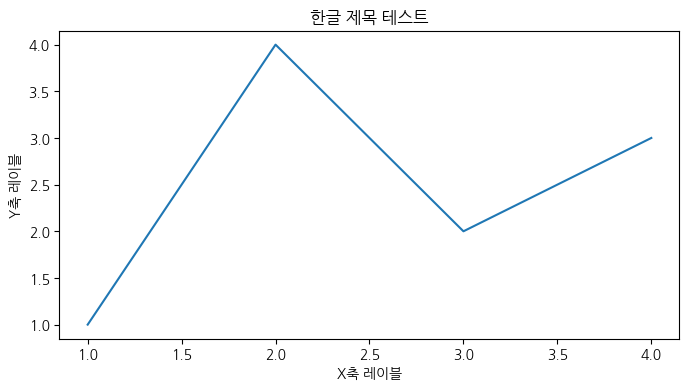

✅ 한글 폰트가 정상적으로 설정되었습니다.


In [2]:
# 나눔고딕 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 설치된 폰트 확인
font_list = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
print("사용 가능한 나눔 폰트:", font_list)

# 테스트 플롯
plt.figure(figsize=(8, 4))
plt.plot([1, 2, 3, 4], [1, 4, 2, 3])
plt.title('한글 제목 테스트')
plt.xlabel('X축 레이블')
plt.ylabel('Y축 레이블')
plt.show()

print("✅ 한글 폰트가 정상적으로 설정되었습니다.")

## 3. MySQL 연결 테스트

In [3]:
# 환경 변수에서 MySQL 접속 정보 가져오기
MYSQL_HOST = os.getenv('MYSQL_HOST', 'mysql')
MYSQL_PORT = os.getenv('MYSQL_PORT', '3306')
MYSQL_DATABASE = os.getenv('MYSQL_DATABASE', 'analysis_db')
MYSQL_USER = os.getenv('MYSQL_USER', 'user')
MYSQL_PASSWORD = os.getenv('MYSQL_PASSWORD', '1111')

# PyMySQL 직접 연결 테스트
try:
    connection = pymysql.connect(
        host=MYSQL_HOST,
        port=int(MYSQL_PORT),
        user=MYSQL_USER,
        password=MYSQL_PASSWORD,
        database=MYSQL_DATABASE
    )
    print("✅ PyMySQL 연결 성공!")
    
    with connection.cursor() as cursor:
        cursor.execute("SELECT VERSION()")
        version = cursor.fetchone()
        print(f"MySQL 버전: {version[0]}")
    
    connection.close()
except Exception as e:
    print(f"❌ PyMySQL 연결 실패: {e}")

✅ PyMySQL 연결 성공!
MySQL 버전: 8.0.44


In [4]:
# SQLAlchemy 엔진 생성 및 테스트
try:
    engine = create_engine(
        f'mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}'
    )
    
    # 테스트 쿼리
    df = pd.read_sql("SELECT 1 as test_column", engine)
    print("✅ SQLAlchemy + Pandas 연결 성공!")
    print(df)
except Exception as e:
    print(f"❌ SQLAlchemy 연결 실패: {e}")

✅ SQLAlchemy + Pandas 연결 성공!
   test_column
0            1


## 4. 테스트 데이터 생성 및 시각화

In [5]:
# 샘플 데이터 생성
data = {
    '제품명': ['사과', '바나나', '오렌지', '포도', '딸기'],
    '판매량': [150, 200, 120, 180, 220],
    '가격': [1500, 2000, 1800, 3000, 2500]
}
df_test = pd.DataFrame(data)
print("테스트 데이터:")
print(df_test)

테스트 데이터:
   제품명  판매량    가격
0   사과  150  1500
1  바나나  200  2000
2  오렌지  120  1800
3   포도  180  3000
4   딸기  220  2500


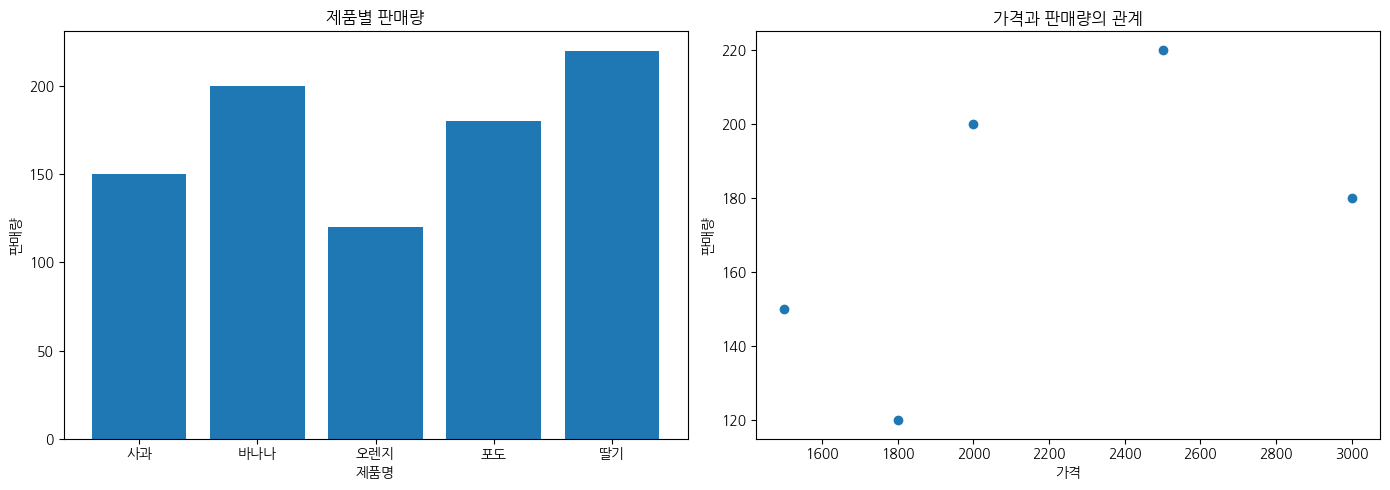

✅ Matplotlib 한글 시각화 성공!


In [6]:
# Matplotlib 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(df_test['제품명'], df_test['판매량'])
axes[0].set_title('제품별 판매량')
axes[0].set_xlabel('제품명')
axes[0].set_ylabel('판매량')

axes[1].scatter(df_test['가격'], df_test['판매량'])
axes[1].set_title('가격과 판매량의 관계')
axes[1].set_xlabel('가격')
axes[1].set_ylabel('판매량')

plt.tight_layout()
plt.show()

print("✅ Matplotlib 한글 시각화 성공!")

/tmp/ipykernel_47/1147112012.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_test, x='제품명', y='판매량', palette='viridis')


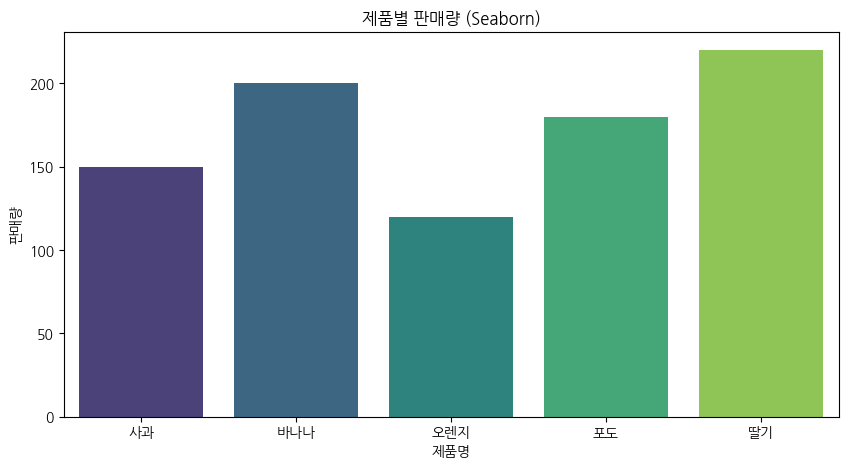

✅ Seaborn 한글 시각화 성공!


In [7]:
# Seaborn 시각화
plt.figure(figsize=(10, 5))
sns.barplot(data=df_test, x='제품명', y='판매량', palette='viridis')
plt.title('제품별 판매량 (Seaborn)')
plt.show()

print("✅ Seaborn 한글 시각화 성공!")

In [8]:
# Plotly 시각화
fig = px.bar(df_test, x='제품명', y='판매량', title='제품별 판매량 (Plotly)',
             color='판매량', color_continuous_scale='viridis')
fig.show()

print("✅ Plotly 한글 시각화 성공!")

✅ Plotly 한글 시각화 성공!


## 5. MySQL에 테스트 데이터 저장

In [9]:
# 테스트 데이터를 MySQL에 저장
try:
    df_test.to_sql('test_products', engine, if_exists='replace', index=False)
    print("✅ 테스트 데이터가 MySQL에 저장되었습니다.")
    
    # 저장된 데이터 확인
    df_from_db = pd.read_sql("SELECT * FROM test_products", engine)
    print("\nMySQL에서 불러온 데이터:")
    print(df_from_db)
except Exception as e:
    print(f"❌ 데이터 저장 실패: {e}")

✅ 테스트 데이터가 MySQL에 저장되었습니다.

MySQL에서 불러온 데이터:
   제품명  판매량    가격
0   사과  150  1500
1  바나나  200  2000
2  오렌지  120  1800
3   포도  180  3000
4   딸기  220  2500


## 6. BigQuery 연결 준비 (선택사항)

BigQuery를 사용하려면:
1. Google Cloud 서비스 계정 키(JSON)를 `credentials/` 디렉토리에 저장
2. `.env` 파일에 `GOOGLE_APPLICATION_CREDENTIALS` 설정
3. 아래 코드의 주석을 해제하고 실행

In [10]:
# from google.cloud import bigquery
# import pandas_gbq

# # 인증 파일 경로 설정
# credentials_path = os.getenv('GOOGLE_APPLICATION_CREDENTIALS')
# if credentials_path:
#     os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = credentials_path
#     
#     # BigQuery 클라이언트 생성
#     client = bigquery.Client()
#     print("✅ BigQuery 클라이언트 생성 성공!")
#     
#     # 테스트 쿼리 (public dataset)
#     query = """
#     SELECT name, SUM(number) as total
#     FROM `bigquery-public-data.usa_names.usa_1910_current`
#     WHERE year = 2000
#     GROUP BY name
#     ORDER BY total DESC
#     LIMIT 5
#     """
#     df_bq = client.query(query).to_dataframe()
#     print(df_bq)
# else:
#     print("ℹ️ BigQuery 인증 정보가 설정되지 않았습니다.")

## 7. 환경 설정 완료!

모든 테스트가 성공했다면 실습 환경이 정상적으로 구축된 것입니다.

### 다음 단계:
- `notebooks/` 디렉토리에 실습용 노트북 생성
- `data/` 디렉토리에 데이터 파일 저장
- `streamlit_apps/` 디렉토리에 Streamlit 앱 개발